# Machine Learning-Based Prediction of Polycystic Ovary Syndrome (PCOS)

**Group 5** — Fatema Ferdous (0152410052), Wafa Haque (0152420023), Khondoker Sazzad Sunfi (0152310002)

---

This notebook walks through the full study. Each section maps onto one of the objectives
in the project proposal:

| Section | Objective |
|---|---|
| 1–2 | Preprocessing and EDA pipeline |
| 3 | Feature selection: correlation, Chi-Square, RFE |
| 4 | Class imbalance handled with SMOTE **inside** the CV folds |
| 5 | Five models under repeated stratified k-fold CV |
| 6 | Held-out test evaluation |
| 7 | **Leakage experiment** — measuring how much a flawed protocol inflates accuracy |
| 8 | Explainable AI with SHAP |
| 9 | Honest comparison against the five reviewed papers |

The single most important idea in the notebook is that *every* fitted step —
imputation, scaling, feature selection, and SMOTE — lives inside a pipeline, so it is
refitted on each training fold and never observes the data it is scored on.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("..")   # so `src` is importable when running from notebooks/

from src import config, data, eda, evaluate, explain, features, literature, models, plots

config.ensure_dirs()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

print("Random seed:", config.RANDOM_STATE)


Random seed: 42


## 1. Loading and cleaning the data

The dataset is the Kaggle PCOS dataset (Prasoon Kottarathil): 541 patients from 10
hospitals in Kerala, India, with 43 clinical, hormonal and physical measurements.

The raw workbook has several defects that must be fixed before anything will run:

* **Two columns are stored as text** — `II beta-HCG` contains the string `"1.99."`
  (a stray trailing dot) and `AMH` contains a literal `"a"`. Pandas therefore reads
  both entire columns as `object` dtype.
* **`Unnamed: 44`** is an empty column with 2 stray values out of 541.
* **Column names carry inconsistent whitespace** (`" Age (yrs)"`, `"Height(Cm) "`).
* **`Cycle(R/I)`** is coded 2 = regular, 4 = irregular, but one row contains a 5,
  which is not a defined code.
* **Impossible zeros** in `Cycle length(days)` and `Endometrium (mm)` — a 0 mm
  endometrium is a recording failure, not a measurement.


In [2]:
raw = data.load_raw()
print("Raw shape:", raw.shape)
raw.head()


Raw shape: (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [3]:
df = data.clean(raw)
X, y = data.split_xy(df)

print(f"Cleaned shape : {df.shape}  ({X.shape[1]} features + target)")
print(f"Class balance : {(y==0).sum()} no-PCOS / {(y==1).sum()} PCOS  "
      f"({(y==0).sum()/(y==1).sum():.2f} : 1)")
print(f"Missing values: {df.isna().sum().sum()} across {(df.isna().sum()>0).sum()} columns")

data.data_quality_report(raw, df).head(10)


Cleaned shape : (541, 42)  (41 features + target)
Class balance : 364 no-PCOS / 177 PCOS  (2.06 : 1)
Missing values: 8 across 7 columns


,feature,column,dtype,missing,missing_pct,n_unique,was_text_in_source,derived
40,Endometrium (mm),Endometrium (mm),float64,2,0.37,90,False,False
9,Cycle length (days),Cycle length(days),float64,1,0.18,11,False,False
14,beta-HCG II,II beta-HCG(mIU/mL),float64,1,0.18,202,True,False
22,AMH,AMH(ng/mL),float64,1,0.18,300,True,False
41,Irregular cycle,Cycle_Irregular,float64,1,0.18,2,False,True
32,Fast food,Fast food (Y/N),float64,1,0.18,2,False,False
10,Years married,Marraige Status (Yrs),float64,1,0.18,34,False,False
2,Weight (kg),Weight (Kg),float64,0,0.00,117,False,False
1,Age (yrs),Age (yrs),int64,0,0.00,29,False,False
0,PCOS,PCOS,int64,0,0.00,2,False,True


Note what is **not** happening here: no imputation. The 8 remaining missing values are
left in place deliberately. Filling them now would mean computing a median over the whole
dataset — including the rows we will later use for testing. Imputation belongs inside the
pipeline, fitted per fold.


## 2. Exploratory data analysis

Three questions drive the EDA:

1. How bad is the class imbalance? (It sets up the SMOTE decision.)
2. Which features separate the classes?
3. How much redundancy is there between features? (It motivates feature selection.)


In [4]:
fig_paths = eda.run_all(df)
for p in fig_paths:
    print(p.name)


01_class_balance.png
02_missingness.png
03_target_correlations.png
04_correlation_heatmap.png
05_key_distributions.png
06_symptom_prevalence.png
07_follicle_separation.png


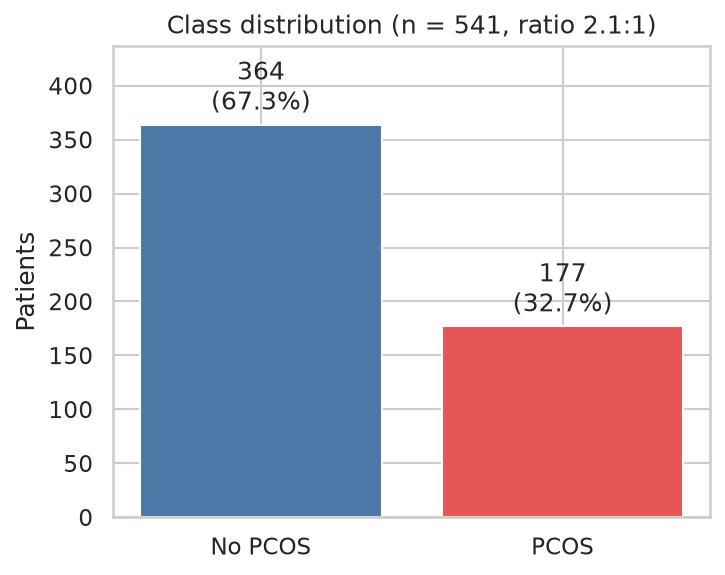

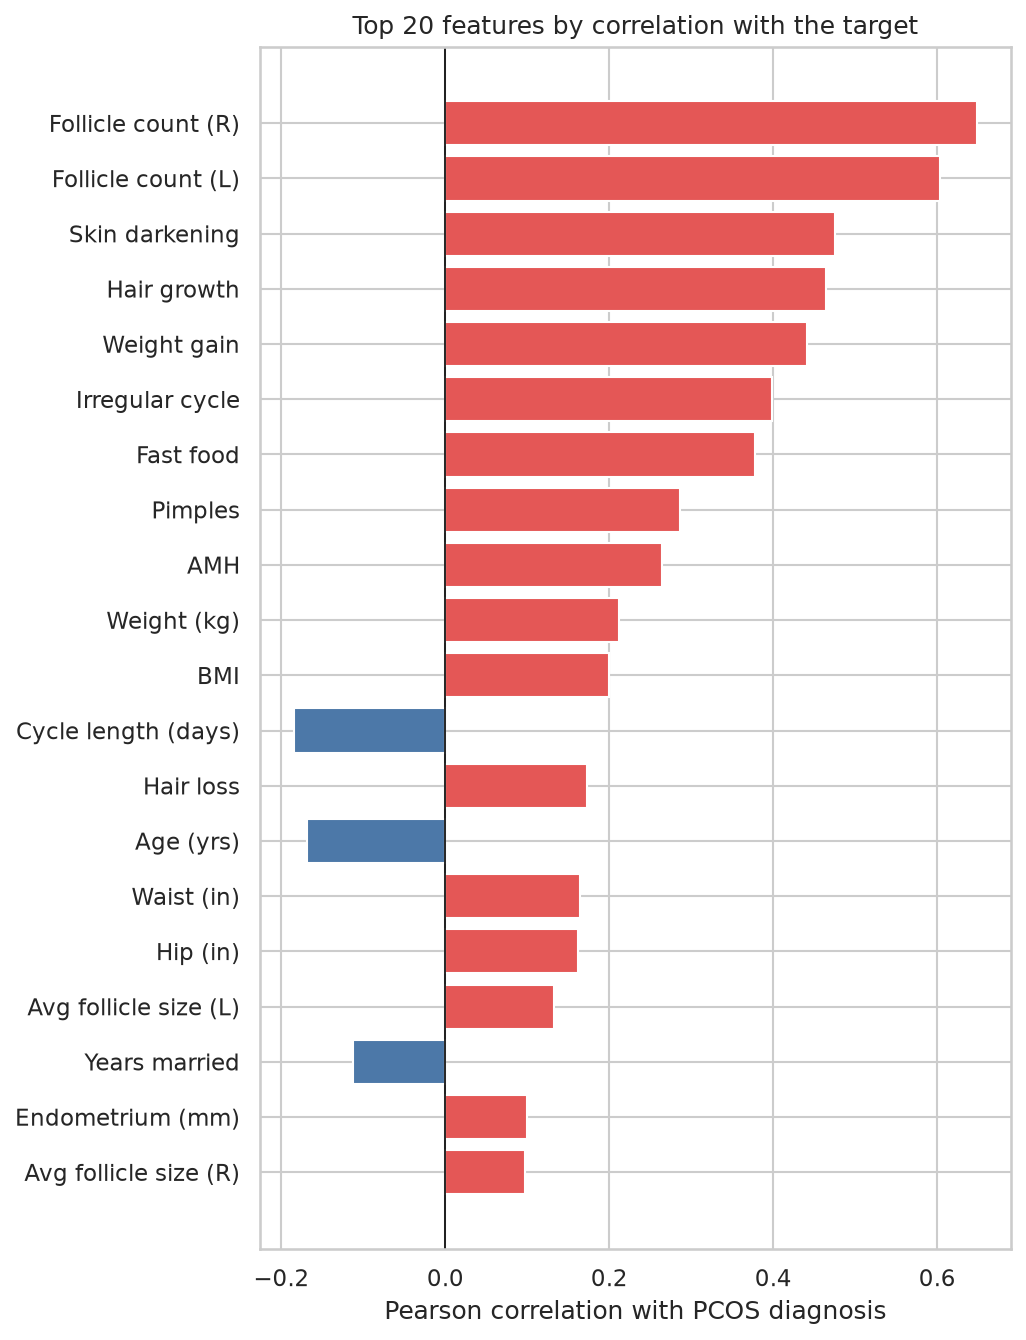

In [5]:
from IPython.display import Image, display
display(Image(str(config.FIGURES_DIR / "01_class_balance.png")))
display(Image(str(config.FIGURES_DIR / "03_target_correlations.png")))


In [6]:
stats = eda.summary_statistics(df)
print("Largest standardised differences between the two groups (Cohen's d):")
stats.head(12)


Largest standardised differences between the two groups (Cohen's d):


,feature,mean_no_pcos,mean_pcos,std_no_pcos,std_pcos,cohens_d
0,Follicle count (R),4.637,10.763,2.926,4.166,1.702
1,Follicle count (L),4.352,9.785,2.814,4.309,1.493
2,Skin darkening,0.154,0.621,0.361,0.486,1.091
3,Hair growth,0.129,0.571,0.336,0.496,1.042
4,Weight gain,0.228,0.684,0.420,0.466,1.026
5,Fast food,0.383,0.785,0.487,0.412,0.893
6,Irregular cycle,0.154,0.534,0.361,0.500,0.871
7,Pimples,0.390,0.695,0.488,0.462,0.641
8,AMH,4.541,7.845,4.291,7.791,0.525
9,Weight (kg),58.009,62.986,10.047,12.175,0.446


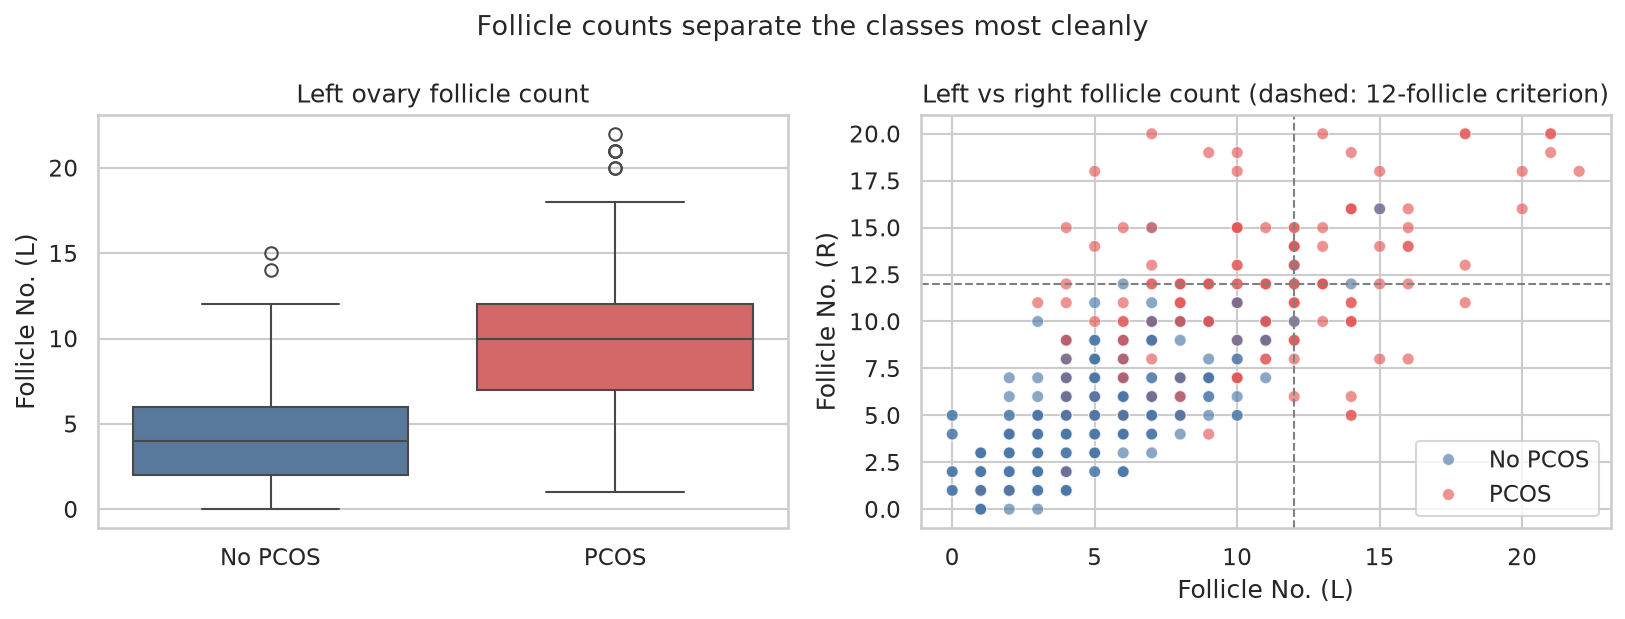

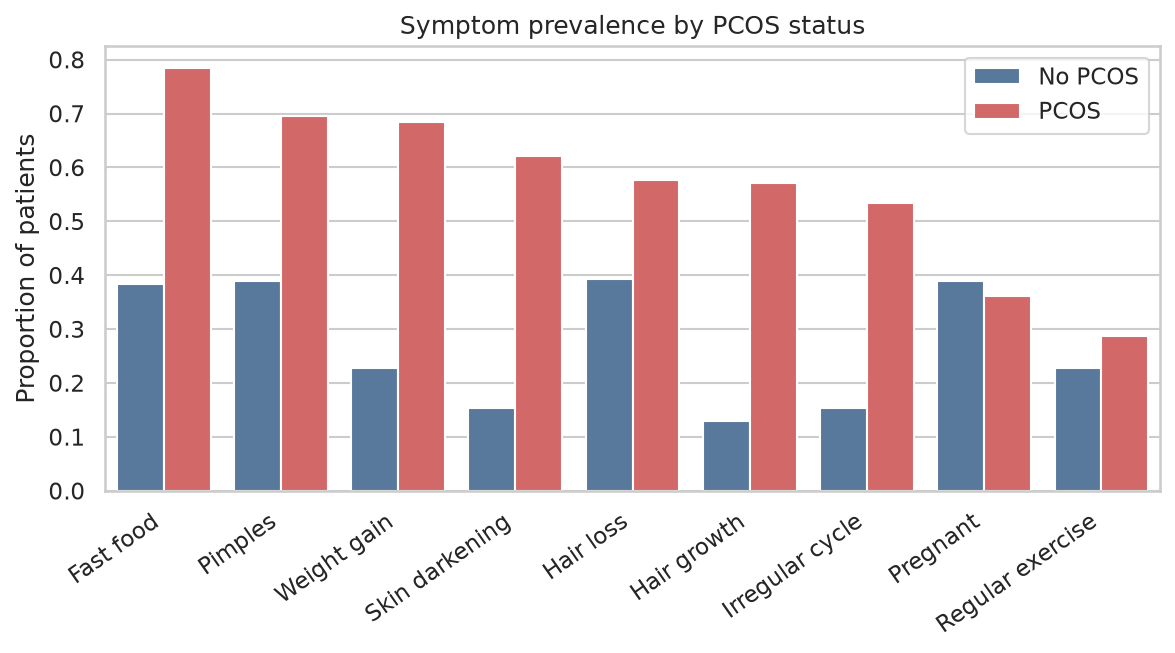

In [7]:
display(Image(str(config.FIGURES_DIR / "07_follicle_separation.png")))
display(Image(str(config.FIGURES_DIR / "06_symptom_prevalence.png")))


**Reading the EDA.** Follicle counts dominate everything else (Cohen's *d* ≈ 1.5–1.7,
a very large effect). This is expected and reassuring — follicle count is one leg of the
Rotterdam diagnostic criteria, so a model that leans on it is behaving sensibly rather
than exploiting an artefact.

The next tier is the self-reported symptom cluster: skin darkening, hair growth and
weight gain, all around *d* ≈ 1.0. The hormone panels (FSH, LH, TSH, prolactin) are
much weaker individually than their clinical prominence would suggest.

One caveat worth flagging in the write-up: `Cycle length(days)` has a median of 5 and a
range of 2–12. Those are not menstrual *cycle* intervals (which would be ~28 days) —
the column is almost certainly recording the duration of bleeding. The Kaggle
documentation does not clarify this, so we report it as-is and note the ambiguity.


## 3. Train / test split — done first, on purpose

The split happens **before** any feature selection, scaling or resampling decision.
The test set is then untouched until Section 6.


In [8]:
X_train, X_test, y_train, y_test = evaluate.make_splits(X, y)
print(f"Train: {X_train.shape[0]} rows ({(y_train==1).sum()} PCOS)")
print(f"Test : {X_test.shape[0]} rows ({(y_test==1).sum()} PCOS)")


Train: 432 rows (141 PCOS)
Test : 109 rows (36 PCOS)


## 4. Feature selection

Three strategies are compared against an all-features baseline:

* **Correlation** — keep features correlated with the target above a threshold, then drop
  one of every pair of mutually redundant features.
* **Chi-Square** — top-*k* by χ² statistic (min-max scaled first, since χ² needs
  non-negative inputs).
* **RFE** — Recursive Feature Elimination driven by logistic regression.

Each is a scikit-learn transformer, so selection is refitted per fold.


In [9]:
X_prep = models.build_preprocessor(X_train).fit_transform(X_train, y_train)

for name in ("correlation", "chi2", "rfe"):
    sel = features.build_selector(name, k=15).fit(X_prep, y_train)
    print(f"\n{name.upper()} kept {len(sel.selected_features_)} features:")
    for f in sel.selected_features_:
        print("   ", config.pretty(str(f)))



CORRELATION kept 19 features:
    Follicle count (R)
    Follicle count (L)
    Skin darkening
    Hair growth
    Weight gain
    Irregular cycle
    Fast food
    AMH
    Pimples
    Weight (kg)
    Waist (in)
    Cycle length (days)
    Hair loss
    Age (yrs)
    Avg follicle size (L)
    Avg follicle size (R)
    Years married
    Endometrium (mm)
    LH

CHI2 kept 15 features:
    Weight (kg)
    Cycle length (days)
    Waist (in)
    AMH
    Vitamin D3
    Follicle count (L)
    Follicle count (R)
    Weight gain
    Hair growth
    Skin darkening
    Hair loss
    Pimples
    Fast food
    Regular exercise
    Irregular cycle



RFE kept 15 features:
    Pulse rate (bpm)
    Years married
    Follicle count (L)
    Follicle count (R)
    Blood Group_11
    Blood Group_12
    Blood Group_13
    Blood Group_14
    Blood Group_15
    Blood Group_17
    Weight gain
    Hair growth
    Skin darkening
    Pimples
    Irregular cycle


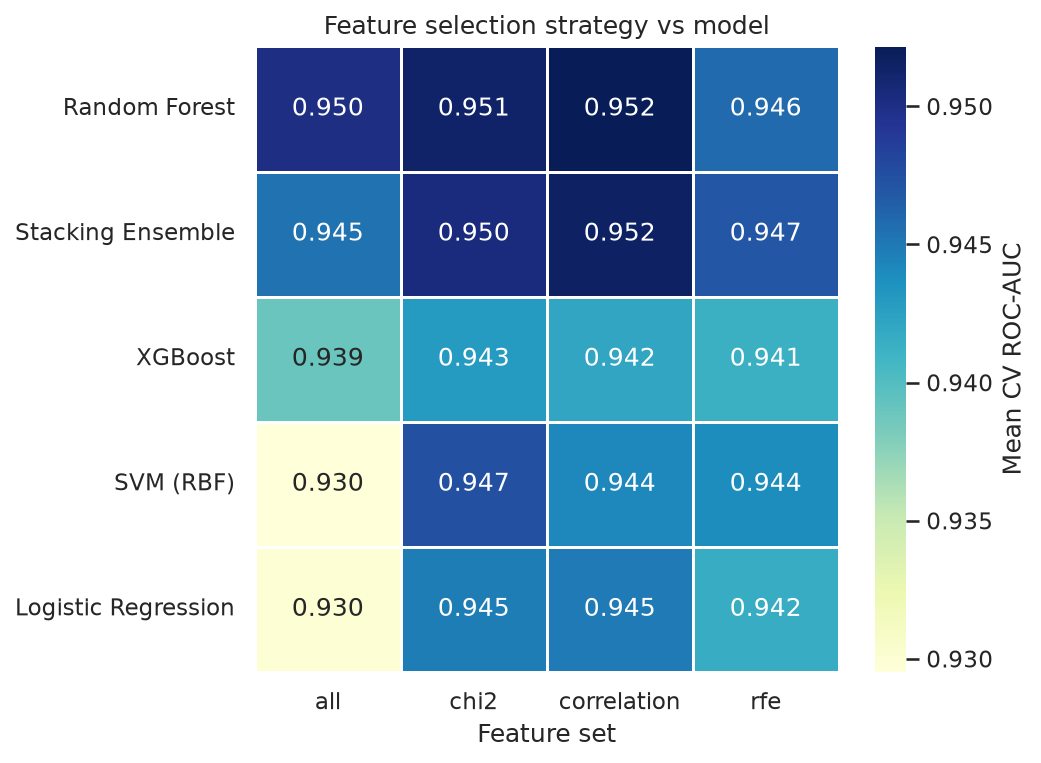

               mean     std     max
feature_set                        
all          0.9388  0.0092  0.9501
chi2         0.9473  0.0036  0.9513
correlation  0.9470  0.0046  0.9522
rfe          0.9439  0.0025  0.9470

Best feature set: chi2


In [10]:
feature_comparison = evaluate.compare_feature_sets(
    models.build_all_models, X_train, y_train, k_features=15, repeats=1
)
plots.plot_feature_set_comparison(feature_comparison)
display(Image(str(config.FIGURES_DIR / "09_feature_set_comparison.png")))

summary = feature_comparison.groupby("feature_set")["roc_auc"].agg(["mean", "std", "max"])
best_set = summary["mean"].idxmax()
print(summary.round(4))
print("\nBest feature set:", best_set)


The differences between feature sets are small — a couple of thousandths of AUC, well
inside the fold-to-fold noise. That is itself a result: on this dataset, *which* selection
method you use matters far less than whether you apply it correctly. The reduced sets are
still preferable because 15 features are easier to collect in a clinic than 41, and fewer
parameters means less room to overfit 432 training rows.


## 5. Model comparison under repeated stratified cross-validation

Five models, each wrapped in the full pipeline:

```
impute → scale/encode → select features → SMOTE → classifier
```

Cross-validation is **repeated** (10 folds × 3 repeats). With only ~430 training rows a
single 10-fold run swings by several points depending on the shuffle, so reporting one
run would be reporting noise.


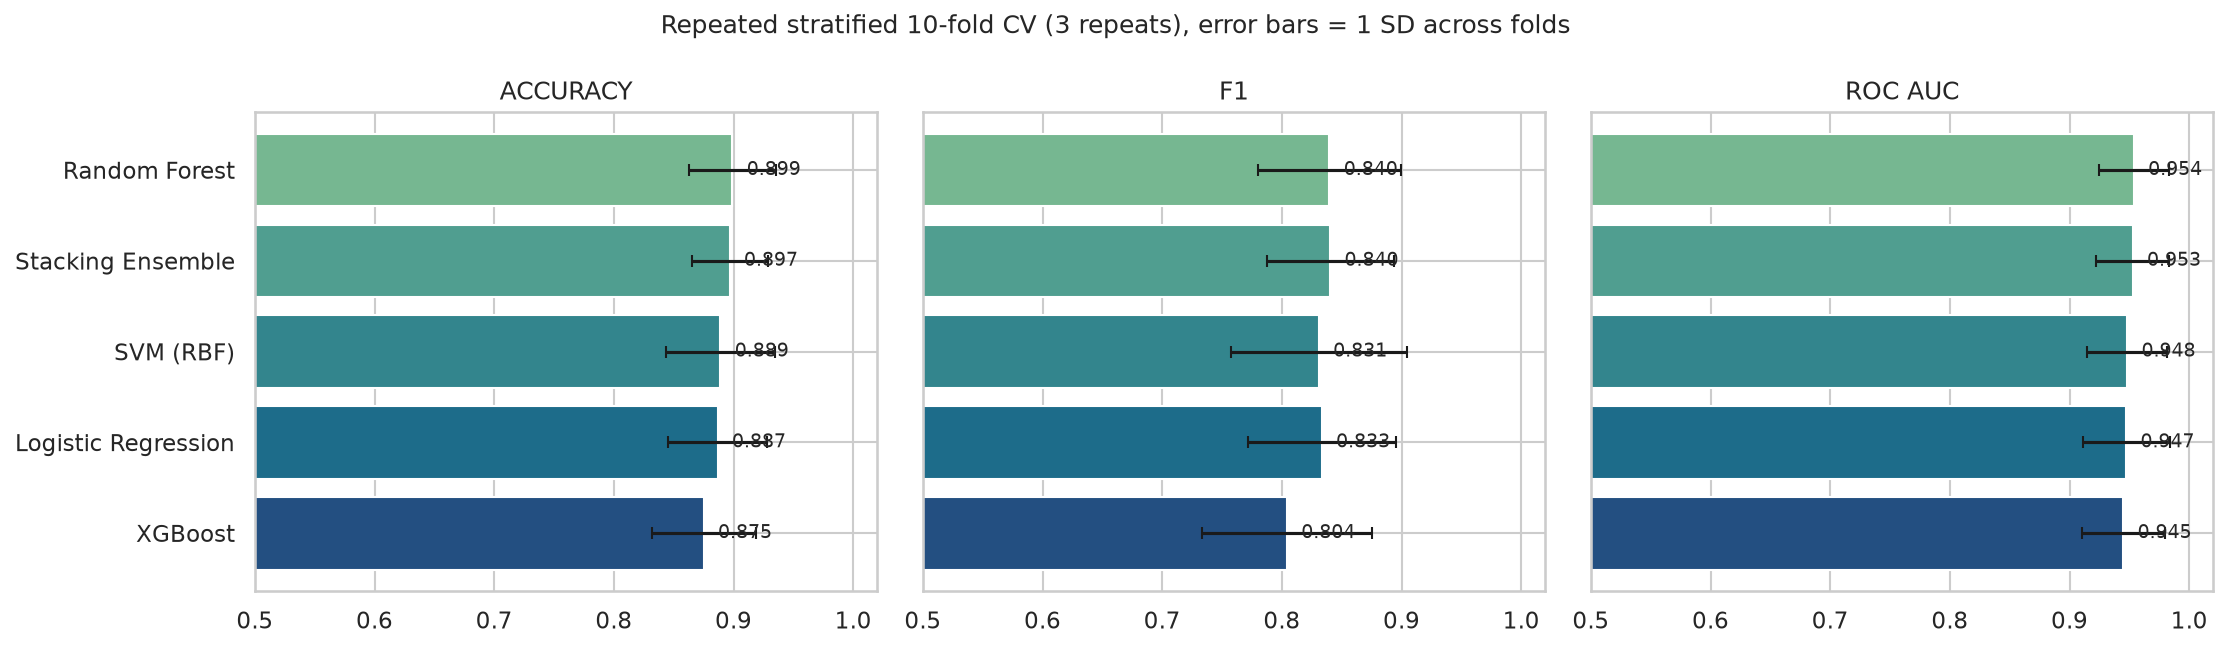

,model,accuracy,accuracy_std,precision,recall,f1,roc_auc,roc_auc_std
0,Random Forest,0.8990,0.0363,0.8709,0.8181,0.8397,0.9537,0.0294
1,Stacking Ensemble,0.8967,0.0317,0.8473,0.8392,0.8403,0.9527,0.0307
2,SVM (RBF),0.8890,0.0453,0.8250,0.8441,0.8309,0.9482,0.0336
3,Logistic Regression,0.8867,0.0411,0.8054,0.8700,0.8333,0.9473,0.0363
4,XGBoost,0.8750,0.0434,0.8249,0.7941,0.8042,0.9449,0.0346


In [11]:
cv_models = models.build_all_models(X_train, selector=best_set, k_features=15)
cv_results = evaluate.cross_validate_models(cv_models, X_train, y_train)

plots.plot_cv_comparison(cv_results)
display(Image(str(config.FIGURES_DIR / "08_cv_model_comparison.png")))

cols = ["model", "accuracy", "accuracy_std", "precision", "recall", "f1", "roc_auc", "roc_auc_std"]
cv_results[cols].round(4)


Look at the standard deviations before the means. All five models sit within roughly one
standard deviation of each other on ROC-AUC — they are **not** meaningfully distinguishable
on this dataset. Announcing a winner to three decimal places would be over-claiming, so
Random Forest is chosen on a tie-break of stability rather than on a real margin.


## 6. Class imbalance: measure it, don't assume it

None of the five reviewed papers state how they handled the 2:1 imbalance. Rather than
assume SMOTE helps, all three options are compared on the same held-out data.


In [12]:
from sklearn.ensemble import RandomForestClassifier

def rf(**kwargs):
    return RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                  random_state=config.RANDOM_STATE, n_jobs=-1, **kwargs)

ablation = evaluate.balance_ablation(X_train, y_train, X_test, y_test, rf)
ablation[["strategy", "accuracy", "precision", "recall", "f1", "specificity", "roc_auc"]].round(4)


,strategy,accuracy,precision,recall,f1,specificity,roc_auc
0,no balancing,0.9174,0.9091,0.8333,0.8696,0.9589,0.9315
1,class weighting,0.9083,0.8611,0.8611,0.8611,0.9315,0.9288
2,SMOTE,0.9266,0.9118,0.8611,0.8857,0.9589,0.9292


The effect is real but modest: SMOTE buys a few points of recall — i.e. it catches PCOS
cases the unbalanced model misses — at essentially no cost in specificity. For a screening
tool that trade is worth taking, since a missed diagnosis is worse than a false alarm that
gets resolved by a confirmatory ultrasound.


## 7. Held-out test set

Everything above used only the training split. This is the first and only look at the
test set.


In [13]:
test_models = models.build_all_models(X_train, selector=best_set, k_features=15)
test_results = evaluate.evaluate_on_test(test_models, X_train, y_train, X_test, y_test)
test_results[["model", "accuracy", "precision", "recall", "f1", "specificity", "roc_auc"]].round(4)


,model,accuracy,precision,recall,f1,specificity,roc_auc
0,Logistic Regression,0.8991,0.8378,0.8611,0.8493,0.9178,0.9490
1,XGBoost,0.9083,0.8611,0.8611,0.8611,0.9315,0.9482
2,Stacking Ensemble,0.9083,0.8824,0.8333,0.8571,0.9452,0.9467
3,Random Forest,0.9174,0.9091,0.8333,0.8696,0.9589,0.9418
4,SVM (RBF),0.9083,0.8824,0.8333,0.8571,0.9452,0.9414


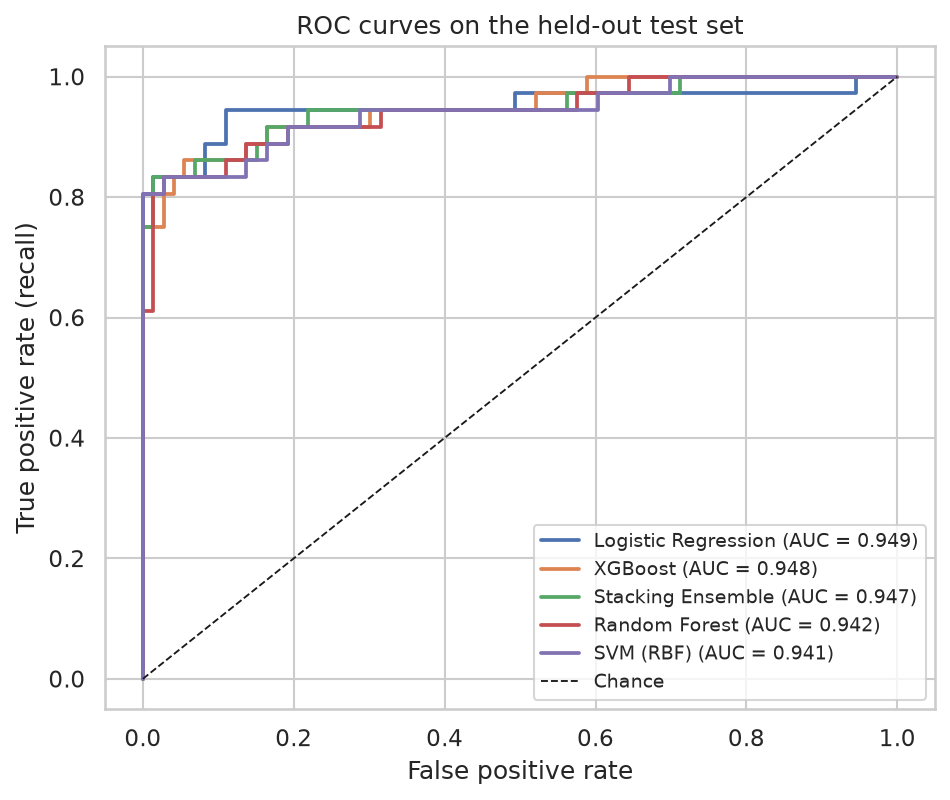

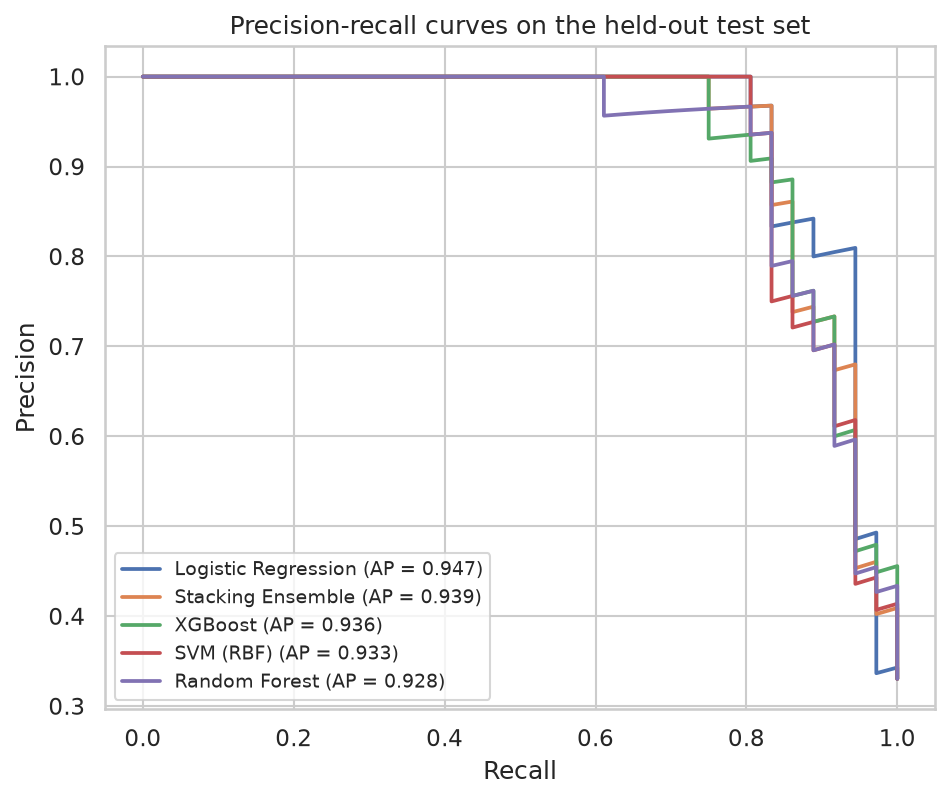

In [14]:
curves = evaluate.curve_data(test_models, X_test, y_test)
plots.plot_roc_curves(curves)
plots.plot_pr_curves(curves)
display(Image(str(config.FIGURES_DIR / "10_roc_curves.png")))
display(Image(str(config.FIGURES_DIR / "11_pr_curves.png")))


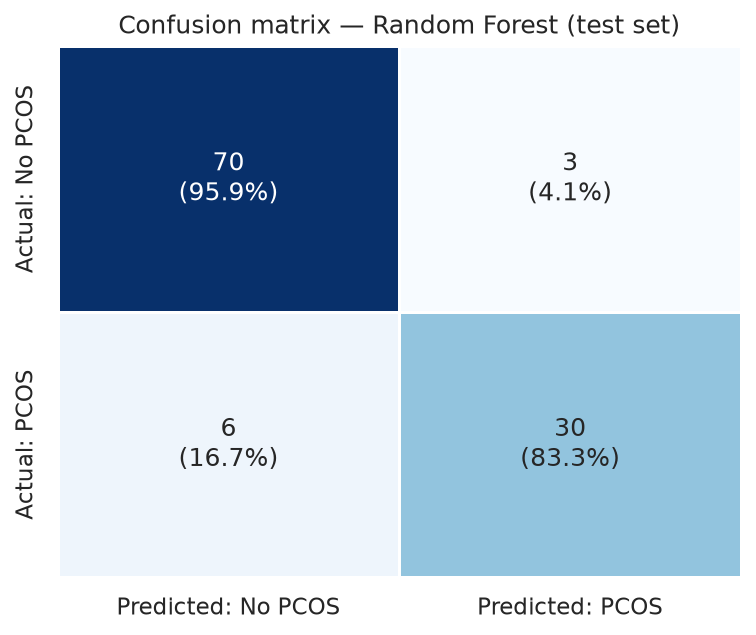

Selected model: Random Forest


In [15]:
best_model_name = cv_results.iloc[0]["model"]
best_pipeline = test_models[best_model_name]
y_pred = best_pipeline.predict(X_test)

plots.plot_confusion_matrix(y_test, y_pred, best_model_name)
display(Image(str(config.FIGURES_DIR / "12_confusion_matrix.png")))
print("Selected model:", best_model_name)


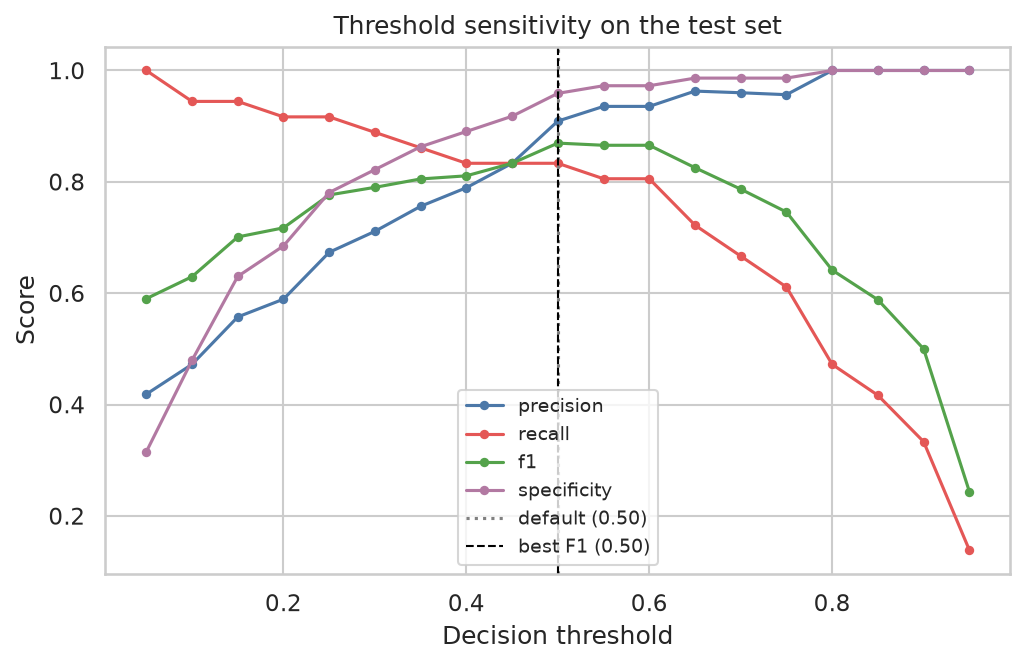

,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,specificity
0,0.05,0.541284,0.418605,1.000000,0.590164,23,50,0,36,0.315068
1,0.10,0.633028,0.472222,0.944444,0.629630,35,38,2,34,0.479452
2,0.15,0.733945,0.557377,0.944444,0.701031,46,27,2,34,0.630137
3,0.20,0.761468,0.589286,0.916667,0.717391,50,23,3,33,0.684932
4,0.25,0.825688,0.673469,0.916667,0.776471,57,16,3,33,0.780822
5,0.30,0.844037,0.711111,0.888889,0.790123,60,13,4,32,0.821918
6,0.35,0.862385,0.756098,0.861111,0.805195,63,10,5,31,0.863014
7,0.40,0.871560,0.789474,0.833333,0.810811,65,8,6,30,0.890411
8,0.45,0.889908,0.833333,0.833333,0.833333,67,6,6,30,0.917808
9,0.50,0.917431,0.909091,0.833333,0.869565,70,3,6,30,0.958904


In [16]:
sweep = evaluate.threshold_sweep(best_pipeline, X_test, y_test)
plots.plot_threshold_sweep(sweep)
display(Image(str(config.FIGURES_DIR / "14_threshold_sweep.png")))
sweep.head(10)


The default 0.5 threshold is a convention, not a clinical decision. Lowering it trades
precision for recall — appropriate for a screening tool whose false positives get filtered
by a follow-up ultrasound, while false negatives walk out of the clinic undiagnosed.


## 8. The leakage experiment

This is the section that addresses the gap analysis directly.

Papers 4 and 5 report 98.9–99.3% accuracy on this same 541-row dataset. Our correctly
validated pipeline reaches noticeably less. Rather than hand-wave about why, we **measure**
the difference by running the same classifier under two protocols:

| Protocol | SMOTE + feature selection | What goes wrong |
|---|---|---|
| **Correct** | Inside the pipeline, refit per fold | Nothing — validation folds stay unseen |
| **Leaky** | Once, on the whole dataset, before CV | Synthetic minority rows interpolated from training patients land in the validation fold; the selector has already read every label |

Both use identical folds, identical data and an identical model. The only difference is
*where* the resampling happens.


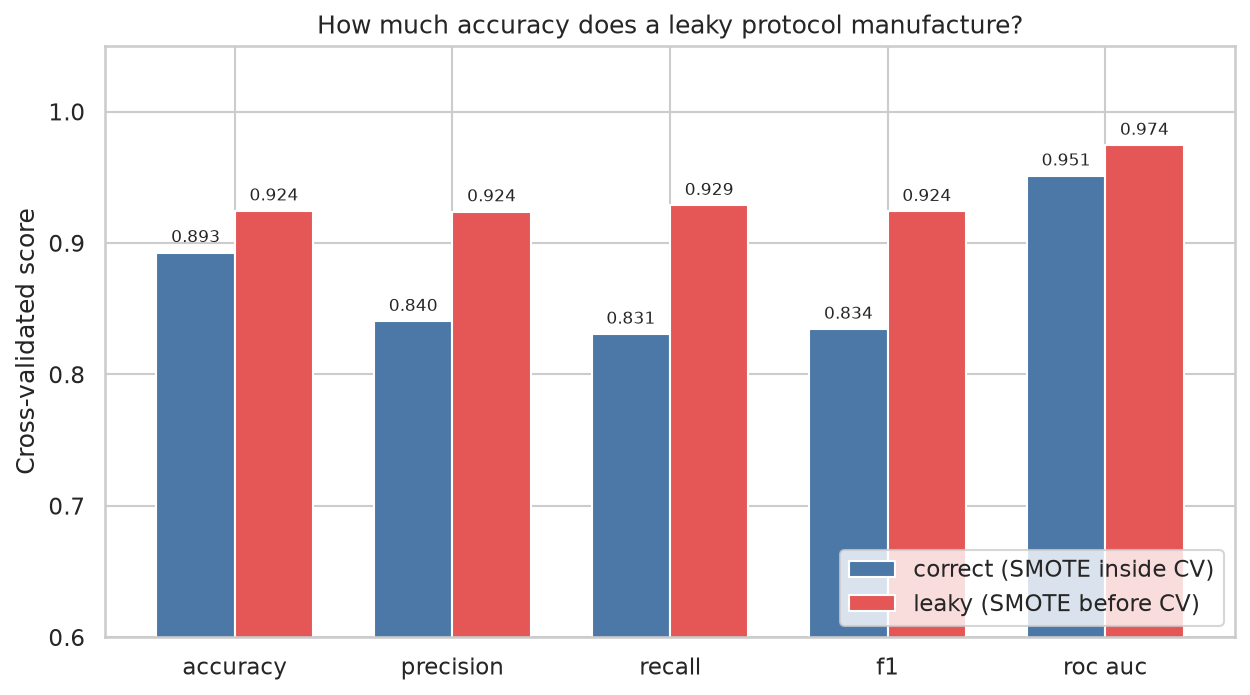

,protocol,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,correct (SMOTE inside CV),0.8928,0.8770,0.8404,0.8307,0.8345,0.9511
1,leaky (SMOTE before CV),0.9245,0.9246,0.9238,0.9287,0.9241,0.9745
2,inflation (leaky - correct),0.0317,0.0477,0.0834,0.0980,0.0896,0.0234


In [17]:
leakage = evaluate.leakage_experiment(X, y, rf)
plots.plot_leakage_experiment(leakage)
display(Image(str(config.FIGURES_DIR / "13_leakage_experiment.png")))
leakage.round(4)


**This is the headline finding of the project.** Simply moving SMOTE from inside the
cross-validation loop to outside it manufactures several points of accuracy and a much
larger jump in recall and F1 — without changing the model, the data, or the folds by
a single row.

That does not prove the reviewed papers made this mistake. Most of them do not describe
their protocol in enough detail to tell, which is precisely the problem. What it does show
is that a 98–99% headline on 541 records is *reachable* through methodology alone, so such
numbers cannot be taken at face value without a stated protocol.


## 9. Explainable AI with SHAP

Accuracy tells a clinician nothing actionable. SHAP decomposes each individual prediction
into signed per-feature contributions, answering both *what does the model rely on overall*
and *why this patient*.


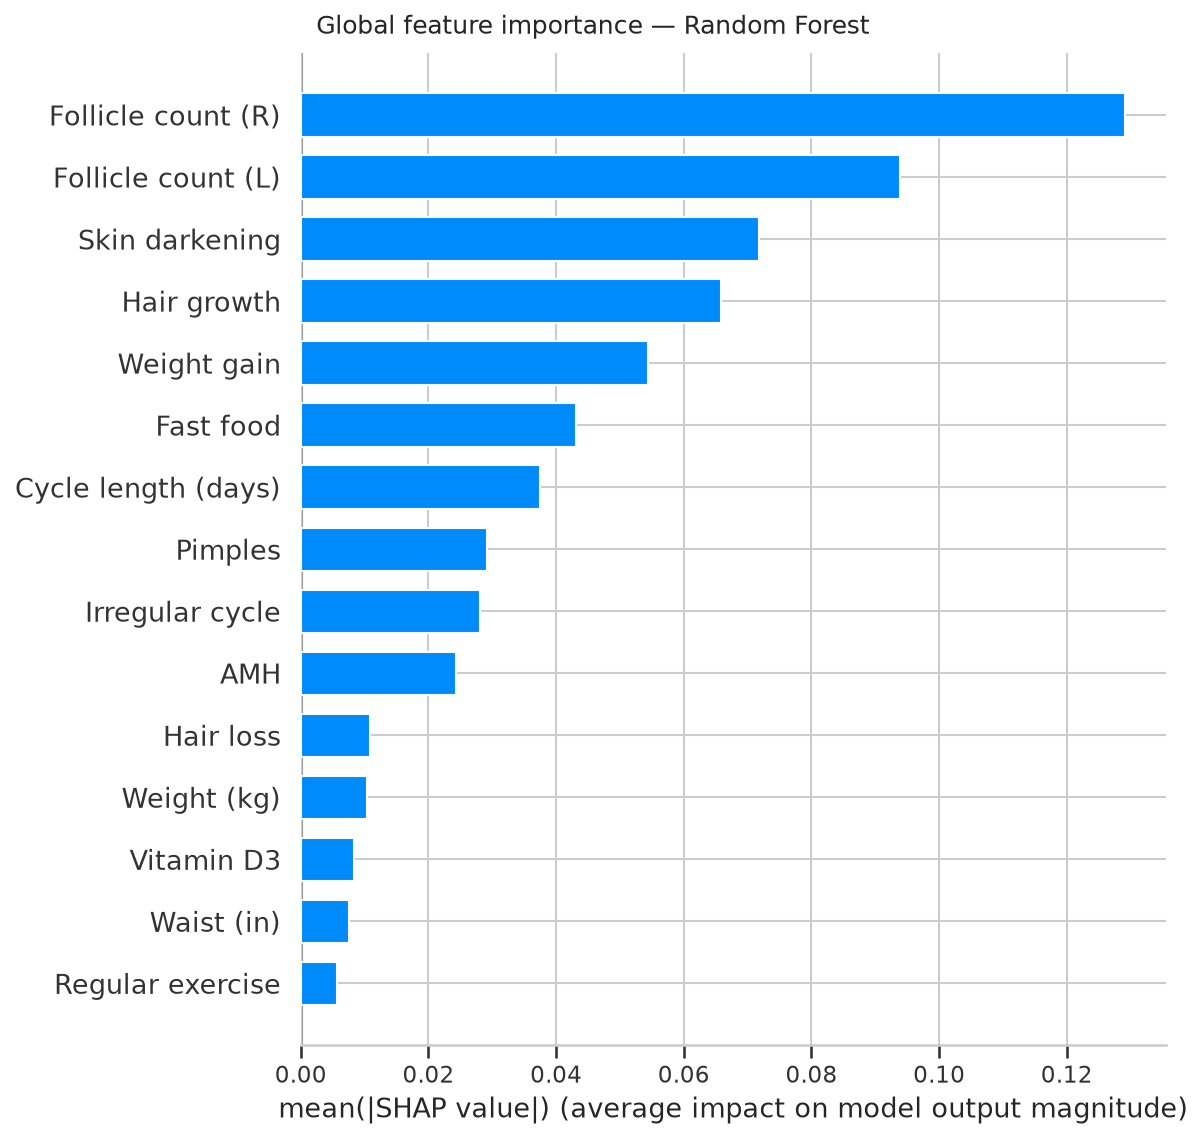

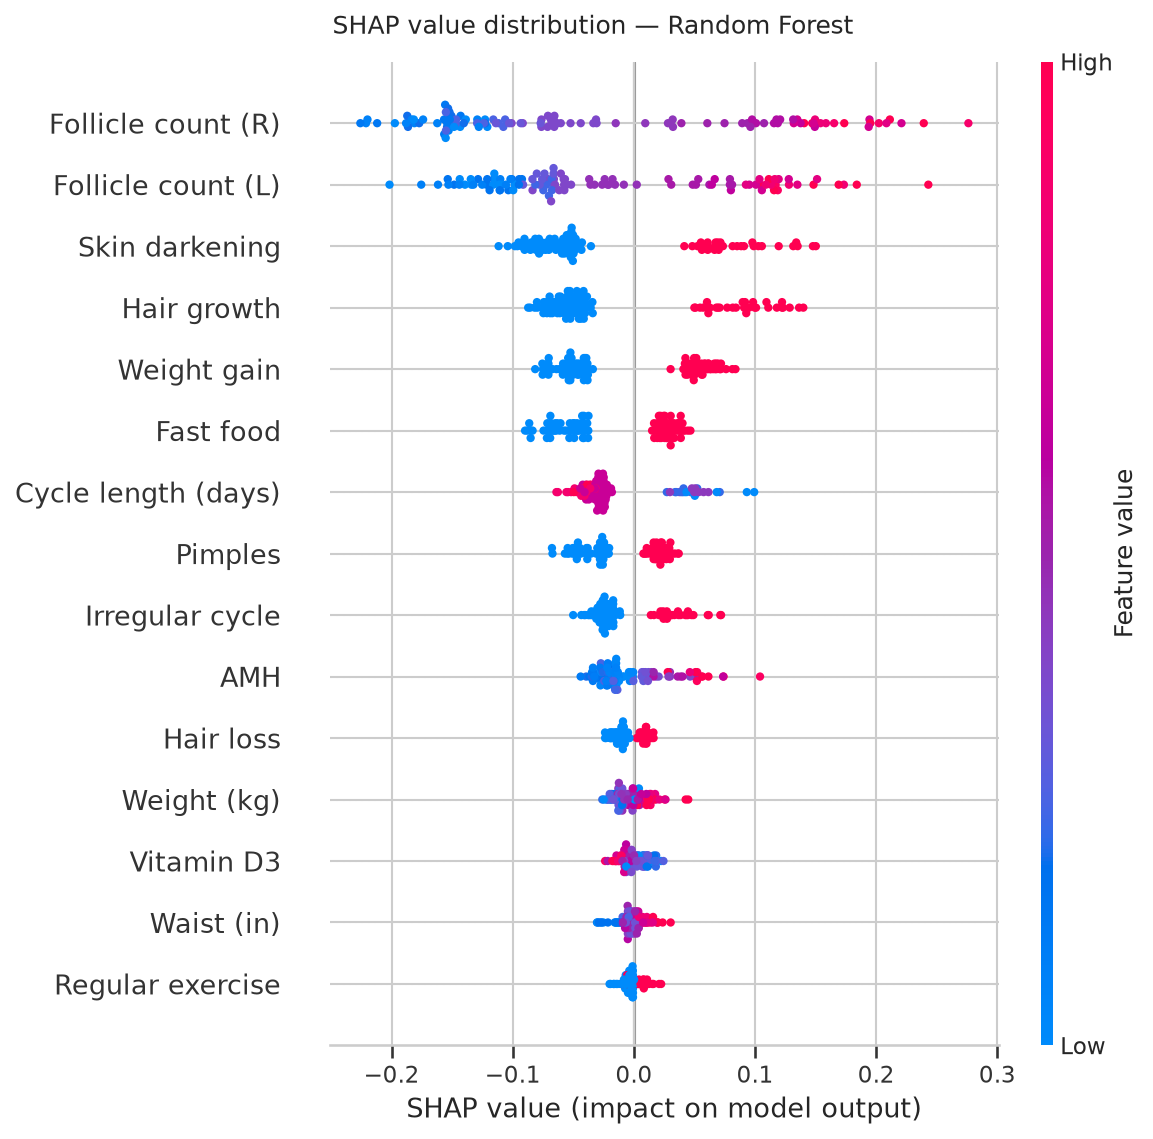

In [18]:
explain_name = "Random Forest"
explain_pipeline = test_models[explain_name]

shap_values, shap_data = explain.shap_values_for(explain_pipeline, X_test)
explain.plot_global_importance(shap_values, shap_data, explain_name)
explain.plot_beeswarm(shap_values, shap_data, explain_name)

display(Image(str(config.FIGURES_DIR / "16_shap_global_importance.png")))
display(Image(str(config.FIGURES_DIR / "17_shap_beeswarm.png")))


In [19]:
importance = explain.importance_table(shap_values, shap_data)
importance.head(12).round(4)


,feature,mean_abs_shap,value_shap_corr,higher_value_means
0,Follicle count (R),0.1291,0.9133,more likely PCOS
1,Follicle count (L),0.0938,0.9161,more likely PCOS
2,Skin darkening,0.0719,0.9548,more likely PCOS
3,Hair growth,0.0658,0.9660,more likely PCOS
4,Weight gain,0.0544,0.9781,more likely PCOS
5,Fast food,0.0432,0.9640,more likely PCOS
6,Cycle length (days),0.0374,-0.7657,less likely PCOS
7,Pimples,0.0292,0.9455,more likely PCOS
8,Irregular cycle,0.0281,0.9393,more likely PCOS
9,AMH,0.0243,0.8258,more likely PCOS


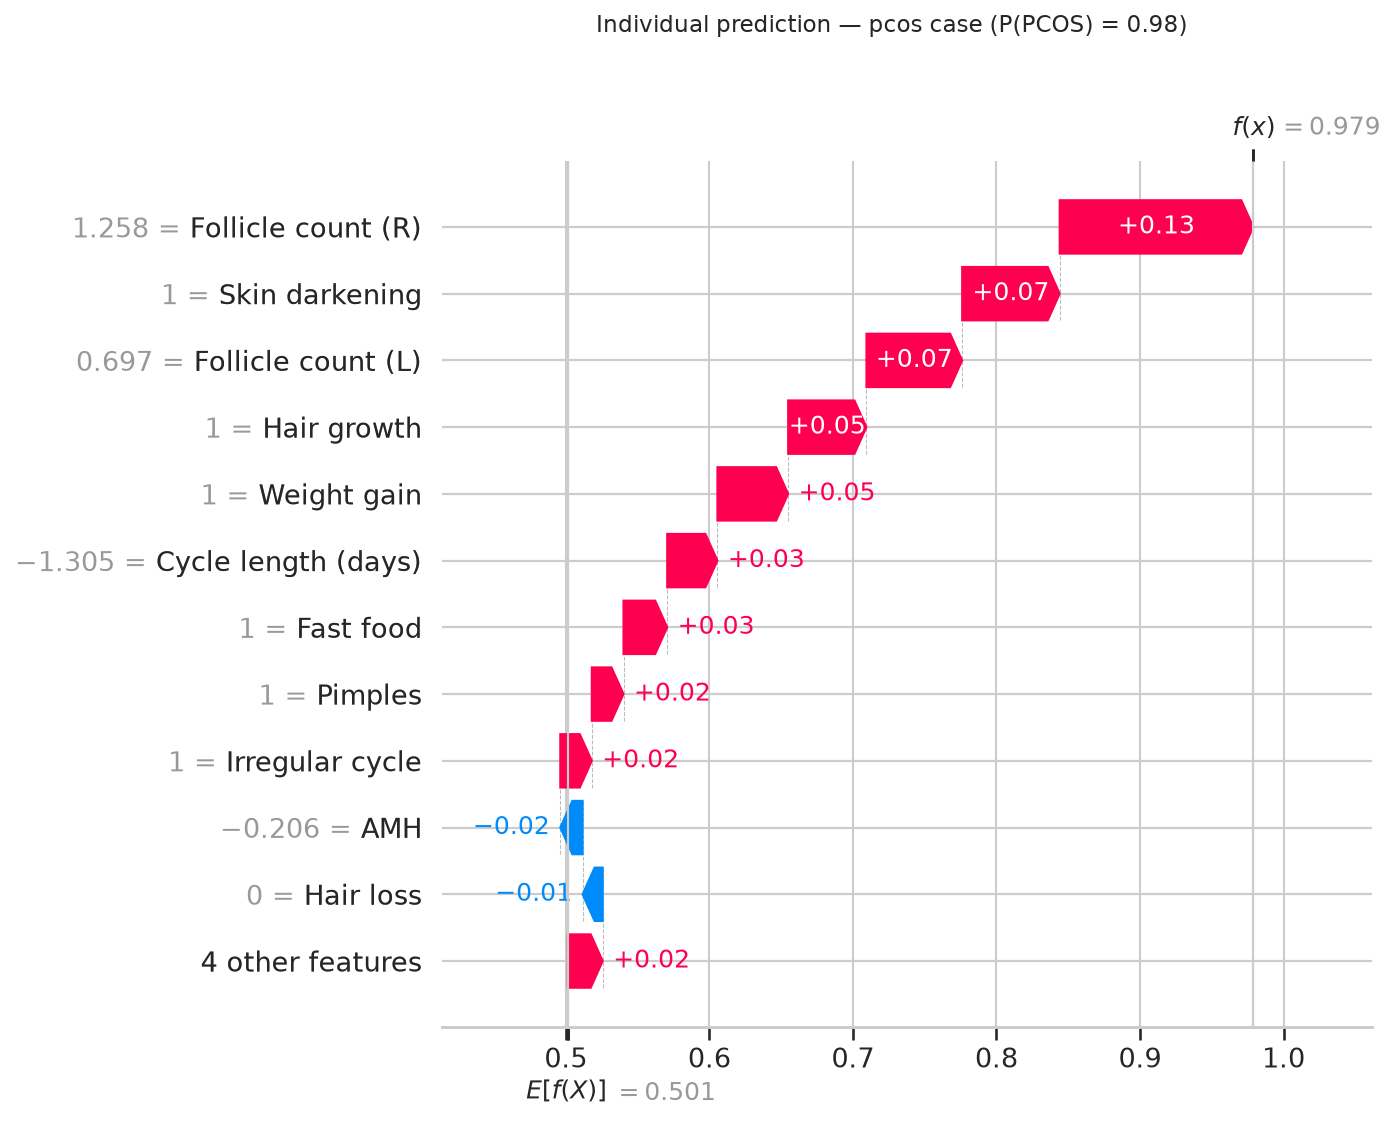

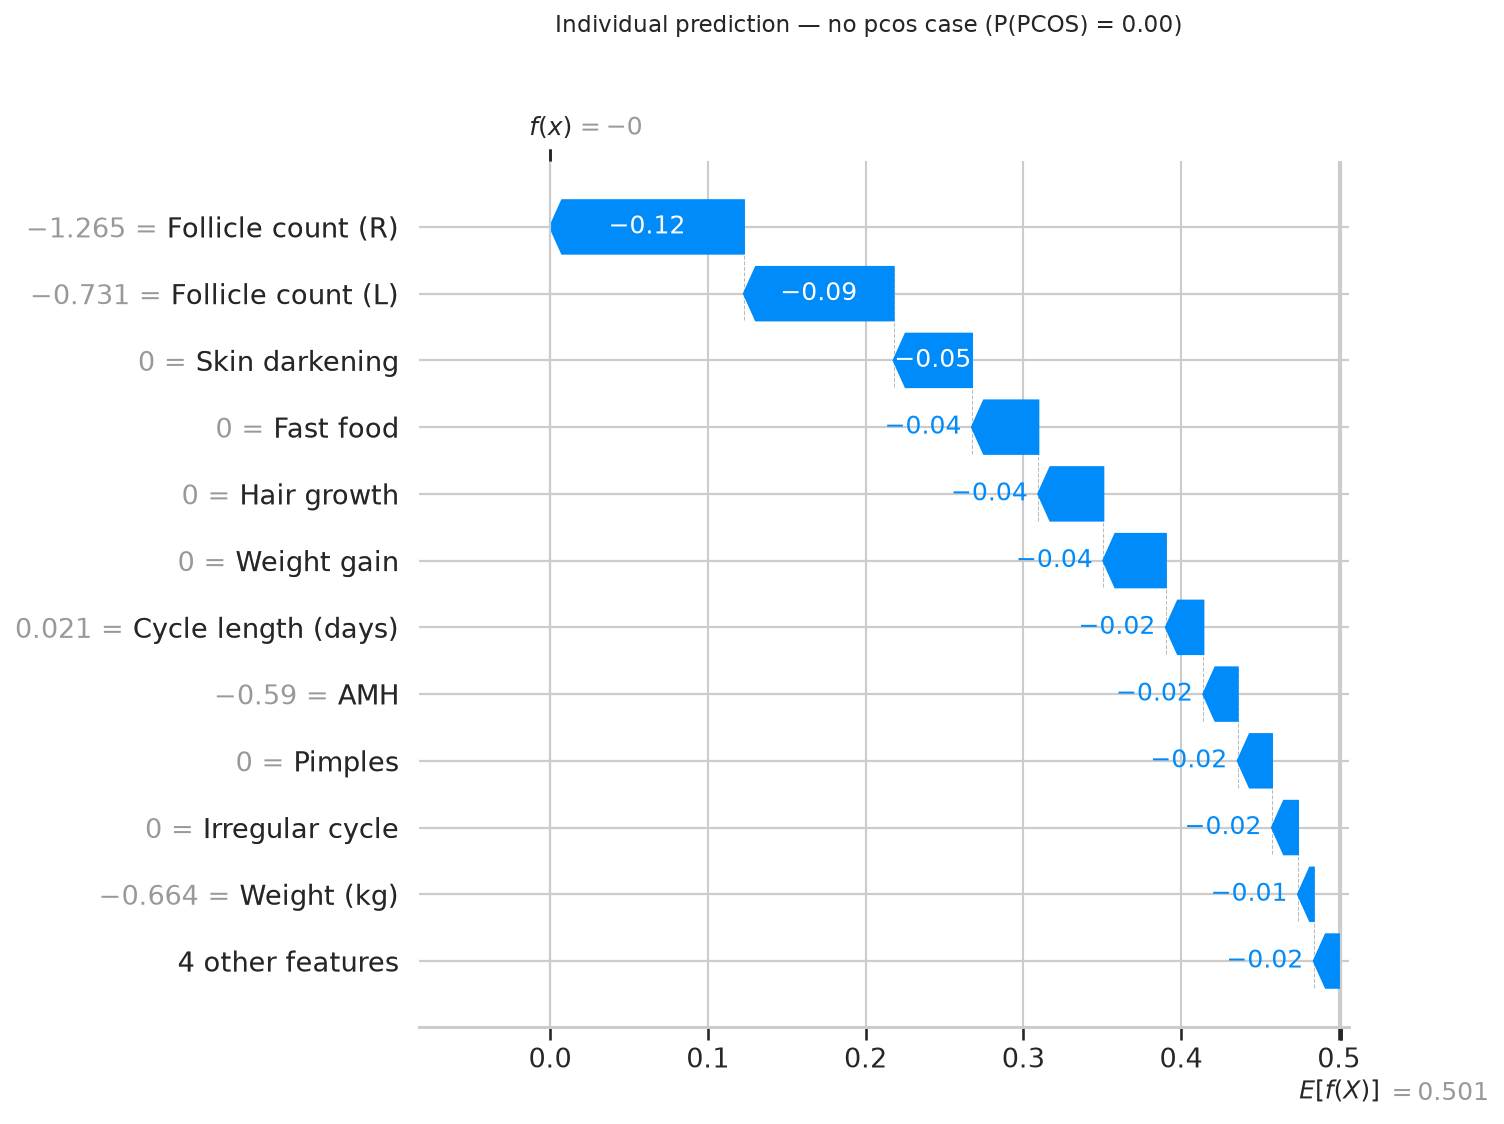

In [20]:
explain.plot_individual_explanations(explain_pipeline, X_test, y_test, shap_values, shap_data)
display(Image(str(config.FIGURES_DIR / "18_shap_waterfall_pcos_case.png")))
display(Image(str(config.FIGURES_DIR / "18_shap_waterfall_no_pcos_case.png")))


**Clinical sanity check.** The model's top features are follicle counts, then the
hyperandrogenism symptom cluster (skin darkening, hair growth), then cycle irregularity.
Those are, in order, the three legs of the Rotterdam criteria. The model independently
rediscovered the diagnostic standard from data rather than latching onto a spurious
correlate — which is a stronger argument for trusting it than any accuracy figure.

The `value_shap_corr` column gives direction: higher follicle counts push toward PCOS,
as expected. Note that mean *signed* SHAP would be misleading here — on a
majority-negative test set almost every feature has a negative mean, which reflects the
class balance rather than the feature.


## 10. Honest comparison against the reviewed literature


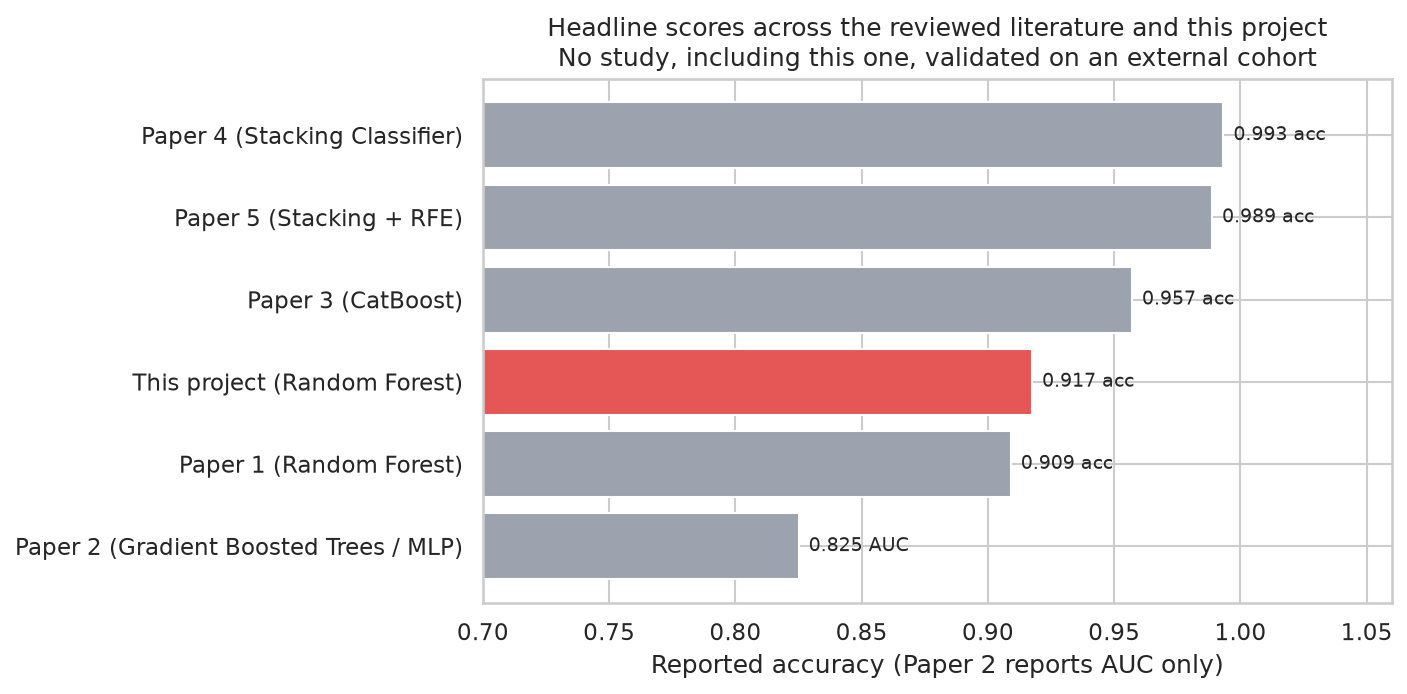

,paper,best_model,reported_accuracy,validation_protocol,imbalance_handled,explainability
0,"Paper 1 — PCOcare (Thakre et al., 2020)",Random Forest,0.909000,single train/test split,not stated,False
1,"Paper 2 — EHR study (Zad et al., 2024)",Gradient Boosted Trees / MLP,0.825000,held-out split on large EHR cohort,not stated,False
2,Paper 3 — Bhat (2021),CatBoost,0.957000,single train/test split,not stated,False
3,Paper 4 — Traditional ML + DL (2024),Stacking Classifier,0.993200,single train/test split,not stated,False
4,"Paper 5 — RFE + XAI (Elmannai et al., 2023)",Stacking + RFE,0.988700,single train/test split,not stated,True
5,This project,Random Forest,0.917431,repeated stratified 10-fold CV + untouched hel...,SMOTE inside CV folds,True


In [21]:
best_row = test_results[test_results["model"] == best_model_name].iloc[0]
cv_row = cv_results[cv_results["model"] == best_model_name].iloc[0]

comparison = literature.comparison_table(
    our_accuracy=float(best_row["accuracy"]),
    our_auc=float(best_row["roc_auc"]),
    our_model=best_model_name,
    our_accuracy_std=float(cv_row["accuracy_std"]),
)
plots.plot_paper_comparison(comparison)
display(Image(str(config.FIGURES_DIR / "15_paper_comparison.png")))

comparison[["paper", "best_model", "reported_accuracy", "validation_protocol",
            "imbalance_handled", "explainability"]]


In [22]:
print(literature.DISCUSSION)


Reading the comparison table
----------------------------

Papers 4 and 5 report 98.9-99.3% accuracy on the same 541-row dataset used
here. This project reports a lower number, and that gap is the most
important result in the report -- it is a methodology difference, not a
modelling failure.

Three things separate the protocols:

1. **Where the resampling happens.** If SMOTE runs before the train/test
   split, synthetic minority rows interpolated from training patients end up
   in the evaluation set. The model is then partly scored on points derived
   from data it trained on. The leakage experiment in this project measures
   that effect directly on the same dataset and the same classifier.

2. **Where feature selection happens.** Running RFE once on the full dataset
   lets the selector read every label, including the test labels, before the
   split. The chosen feature set is then tuned to the test set.

3. **How many splits.** A single 80/20 split of 541 rows puts about 35 PCOS
 

## 11. Conclusions and limitations

**What was delivered against the proposal**

| Objective | Status |
|---|---|
| Preprocessing + EDA pipeline | Done — 5 classes of data defect fixed, 7 EDA figures |
| Compare correlation / Chi-Square / RFE | Done — all three, cross-validated, plus a baseline |
| Address class imbalance explicitly | Done — SMOTE inside folds, with a 3-way ablation |
| Multiple models + ensemble, stratified k-fold | Done — 5 models, 10-fold × 3 repeats |
| SHAP explainability | Done — global, directional and per-patient |
| Honest comparison with the five papers | Done — plus a measured leakage experiment |

**Limitations, stated plainly**

1. **No external validation.** This was in the gap analysis as a criticism of the
   reviewed papers, and we did not fix it either — no second cohort was available to us.
   Our held-out test set comes from the same 541 patients and the same 10 Kerala
   hospitals, so it measures generalisation to new *patients*, not to new *populations*.
   This remains the single biggest open problem in PCOS prediction work.
2. **Small sample.** 541 rows, 109 in the test set, 36 of them PCOS cases. Three patients
   changing sides moves test accuracy by ~3 points. Every test-set number here should be
   read with that granularity in mind — the cross-validated figures are more trustworthy.
3. **No ultrasound imagery.** Also identified in the gap analysis and also not addressed;
   the dataset contains follicle *counts* derived from ultrasound, but not the images.
4. **Self-reported symptoms.** Several of the strongest features (weight gain, hair
   growth, fast food) are patient-reported and may be recorded *after* a clinical
   suspicion of PCOS has formed, which would make them partly a consequence of the
   diagnosis rather than a predictor of it.
5. **Single-centre labels.** All diagnoses come from one region's clinical practice.

**The main takeaway**

A correctly validated model on this dataset lands around 0.95 ROC-AUC and ~90% accuracy —
strong, clinically plausible, and consistent with the Rotterdam criteria under SHAP. The
98–99% figures in the literature are reachable, but our leakage experiment shows a large
share of that margin can be produced by protocol choices alone. Reporting the lower,
defensible number is the more useful scientific contribution.
